# Phân Tích Cảm Xúc Đa Khía Cạnh (ABSA) - BiLSTM + PhoBert

## Cài đặt thư viện


In [1]:
# Cài đặt pyvi để tách từ tiếng Việt, gensim, và sacremoses cho MarianMT
!pip install -q pyvi gensim iterative-stratification seaborn scikit-learn nlpaug transformers sacremoses

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 70.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 57.8 MB/s eta 0:00:00


## Import thư viện


In [2]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

from transformers import AutoTokenizer, AutoModel
from pyvi import ViTokenizer

from transformers import MarianMTModel, MarianTokenizer
from tqdm.auto import tqdm

import time


warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


## Cấu hình


In [3]:
# --- CẤU HÌNH BILSTM & PHOBERT ---
MAX_LENGTH = 160
HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.2

# --- CẤU HÌNH HUẤN LUYỆN ---
EPOCHS = 8
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
USE_ASPECT_ATTENTION = True

ABSENT_CLASS = 3
SENTIMENT_CLASSES = [0, 1, 2]
ASPECT_COLS = ['as_content', 'as_physical', 'as_price', 'as_packaging', 'as_delivery', 'as_service']
LABEL_COLS = ['sentiment_llm', *ASPECT_COLS]

DATA_ROOT = Path('/kaggle/input/datasets/jyang10/tiki-cleaned-book-reviews')
if not DATA_ROOT.exists():
    DATA_ROOT = Path('.') # Fallback
TRAIN_PATH = DATA_ROOT / 'train_clean.json'
VAL_PATH = DATA_ROOT / 'val_clean.json'
TEST_PATH = DATA_ROOT / 'test_clean.json'



current_working_dir = os.getcwd() 
OUTPUT_ROOT = Path(current_working_dir) / 'absa_bilstm_phobert'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

## Nạp và chuẩn bị dữ liệu


In [4]:
def load_and_prepare(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_json(path)

    title = df.get('review_title', df.get('title', pd.Series(['']*len(df)))).fillna('').astype(str).str.strip()
    body = df.get('content', df.get('text', pd.Series(['']*len(df)))).fillna('').astype(str).str.strip()

    df['title'] = title
    df['body'] = body
    df['text_full'] = df['title'] + " " + df['body']

    df['sentiment_llm'] = pd.to_numeric(df['sentiment_llm'], errors='coerce')
    df = df.dropna(subset=['sentiment_llm'])
    df['sentiment_llm'] = df['sentiment_llm'].astype(int)
    df = df[df['sentiment_llm'].isin(SENTIMENT_CLASSES)]

    for col in ASPECT_COLS:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(ABSENT_CLASS).astype(int).clip(0, ABSENT_CLASS)

    return df[['text_full', *LABEL_COLS]].reset_index(drop=True)

train_df = load_and_prepare(TRAIN_PATH)
val_df = load_and_prepare(VAL_PATH)
test_df = load_and_prepare(TEST_PATH)

print(f"Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")

Train: (9360, 8), Val: (2009, 8), Test: (2005, 8)


## Tách từ & Load Tokenizer


In [5]:
print("Đang tách từ (Word Segmentation) bằng Pyvi...")

# Hàm tách từ tiếng Việt
def segment_text(text):
    return ViTokenizer.tokenize(text.lower())

train_df['text_seg'] = train_df['text_full'].apply(segment_text)
val_df['text_seg'] = val_df['text_full'].apply(segment_text)
test_df['text_seg'] = test_df['text_full'].apply(segment_text)

print("Đang nạp PhoBERT Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
EMBEDDING_DIM = 768

print("Đã chuẩn bị xong dữ liệu và Tokenizer!")

Đang tách từ (Word Segmentation) bằng Pyvi...


Đang nạp PhoBERT Tokenizer...


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Đã chuẩn bị xong dữ liệu và Tokenizer!


## Dataset & DataLoader


In [6]:
class TextDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row['text_seg']) # Văn bản đã được tách từ bằng pyvi

        # Sử dụng tokenizer của HuggingFace
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        labels = np.array([int(row['sentiment_llm']), *[int(row[col]) for col in ASPECT_COLS]], dtype=np.int64)

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(labels, dtype=torch.long)
        }

# Khởi tạo lại Dataloader
train_dataset = TextDataset(train_df, tokenizer, MAX_LENGTH)
val_dataset = TextDataset(val_df, tokenizer, MAX_LENGTH)
test_dataset = TextDataset(test_df, tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) 
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Kiến trúc mô hình


In [7]:
class SupConLoss(nn.Module):
    """
    Supervised Contrastive Learning: Kéo các vector cùng nhãn lại gần nhau, đẩy các vector khác nhãn ra xa.
    """
    def __init__(self, temperature=0.1):
        super(SupConLoss, self).__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        device = features.device
        batch_size = features.shape[0]

        # Chuẩn hóa vector về unit sphere (L2 norm)
        features = F.normalize(features, p=2, dim=1)
        
        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(device)

        # Tính dot product (chính là Cosine Similarity vì đã normalize)
        anchor_dot_contrast = torch.div(torch.matmul(features, features.T), self.temperature)
        
        # Ổn định tính toán (Numerical stability)
        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()

        # Loại bỏ self-contrast (đường chéo của ma trận)
        logits_mask = torch.scatter(torch.ones_like(mask), 1, torch.arange(batch_size).view(-1, 1).to(device), 0)
        mask = mask * logits_mask

        # Tính Log-softmax
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-9)

        # Tránh chia cho 0 nếu trong batch chỉ có 1 sample của 1 class
        mask_sum = mask.sum(1)
        mask_sum = torch.where(mask_sum == 0, torch.ones_like(mask_sum), mask_sum)
        
        mean_log_prob_pos = (mask * log_prob).sum(1) / mask_sum
        
        loss = -mean_log_prob_pos.mean()
        return loss

# === CÁC CLASS KHÁC GIỮ NGUYÊN NHƯ CŨ ===
class SpatialDropout1D(nn.Module):
    def __init__(self, p):
        super(SpatialDropout1D, self).__init__()
        self.dropout = nn.Dropout2d(p)
    def forward(self, x):
        x = x.permute(0, 2, 1).unsqueeze(3)  
        x = self.dropout(x)
        x = x.squeeze(3).permute(0, 2, 1)
        return x
        
class PhoBERT_ABSABiLSTM(nn.Module):
    def __init__(self, hidden_dim, num_layers, dropout, num_aspects):
        super(PhoBERT_ABSABiLSTM, self).__init__()
        self.phobert = AutoModel.from_pretrained("vinai/phobert-base")
        embed_dim = self.phobert.config.hidden_size
        self.spatial_dropout = SpatialDropout1D(dropout)
        
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True, bidirectional=True, dropout=dropout if num_layers > 1 else 0)
        lstm_out_dim = hidden_dim * 2
        
        self.num_heads = 4
        self.mha = nn.MultiheadAttention(embed_dim=lstm_out_dim, num_heads=self.num_heads, dropout=dropout, batch_first=True)
        
        self.attention_pool = nn.Sequential(nn.Linear(lstm_out_dim, lstm_out_dim // 2), nn.Tanh(), nn.Linear(lstm_out_dim // 2, 1))
        self.feat_norm = nn.LayerNorm(lstm_out_dim * 3)
        cat_dim = lstm_out_dim * 3 
        
        self.sent_proj = nn.Linear(cat_dim, hidden_dim)
        self.sent_decoupler = nn.Sequential(nn.Linear(cat_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim), nn.GELU())
        self.sent_classifier = nn.Sequential(nn.LayerNorm(hidden_dim), nn.Dropout(dropout / 2), nn.Linear(hidden_dim, 3))
        
        self.asp_proj = nn.Linear(cat_dim, hidden_dim)
        self.asp_decoupler = nn.Sequential(nn.Linear(cat_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim), nn.GELU())
        self.pres_classifier = nn.Sequential(nn.LayerNorm(hidden_dim), nn.Dropout(dropout / 2), nn.Linear(hidden_dim, num_aspects * 2))
        self.asp_classifier = nn.Sequential(nn.LayerNorm(hidden_dim), nn.Dropout(dropout / 2), nn.Linear(hidden_dim, num_aspects * 3))
        self.num_aspects = num_aspects

    def forward(self, input_ids, attention_mask):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        embedded = outputs.last_hidden_state 
        embedded = self.spatial_dropout(embedded)
        
        lengths = attention_mask.sum(dim=1).clamp(min=1).cpu()
        packed_embedded = nn.utils.rnn.pack_padded_sequence(embedded, lengths, batch_first=True, enforce_sorted=False)
        packed_output, _ = self.lstm(packed_embedded)
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        
        batch_size, max_len, _ = lstm_out.size()
        mask = torch.arange(max_len).expand(batch_size, max_len).to(lstm_out.device) < lengths.unsqueeze(1).to(lstm_out.device)
        key_padding_mask = ~mask  
        
        attn_output, _ = self.mha(query=lstm_out, key=lstm_out, value=lstm_out, key_padding_mask=key_padding_mask)
        mask_expanded = mask.unsqueeze(-1)
        
        attn_weights = self.attention_pool(attn_output)
        attn_weights = attn_weights.masked_fill(~mask_expanded, -1e9)
        attn_weights = torch.softmax(attn_weights, dim=1)
        mhsa_pool = torch.sum(attn_weights * attn_output, dim=1)
        
        max_pool = torch.max(lstm_out.masked_fill(~mask_expanded, -1e9), dim=1)[0]
        mask_float = mask.float().unsqueeze(-1)
        avg_pool = torch.sum(lstm_out * mask_float, dim=1) / torch.sum(mask_float, dim=1).clamp(min=1e-9)
        
        context_vector = torch.cat([mhsa_pool, max_pool, avg_pool], dim=-1)
        context_vector = self.feat_norm(context_vector)
        
        residual_sent = self.sent_proj(context_vector)
        isolated_sent_context = self.sent_decoupler(context_vector) + residual_sent
        sent_logits = self.sent_classifier(isolated_sent_context)
        
        residual_asp = self.asp_proj(context_vector)
        isolated_asp_context = self.asp_decoupler(context_vector) + residual_asp
        pres_logits = self.pres_classifier(isolated_asp_context).view(-1, self.num_aspects, 2)
        asp_logits = self.asp_classifier(isolated_asp_context).view(-1, self.num_aspects, 3)
        
        # BỔ SUNG: Trả về thêm isolated_sent_context để tính SCL Loss
        return sent_logits, pres_logits, asp_logits, isolated_sent_context

model = PhoBERT_ABSABiLSTM(
    hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, dropout=DROPOUT, num_aspects=len(ASPECT_COLS)
).to(DEVICE)
   
if torch.cuda.device_count() > 1:
    print(f" Kích hoạt Multi-GPU: Sử dụng {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)
print("Mô hình đã được khởi tạo thành công!")

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

 Kích hoạt Multi-GPU: Sử dụng 2 GPUs!
Mô hình đã được khởi tạo thành công!


## Loss, metrics


In [8]:
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.weight = weight 
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # 1. Tính CE Loss thuần để lấy đúng xác suất pt của class mục tiêu
        ce_loss_raw = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss_raw)
        
        # 2. Tính CE Loss có trọng số (Class Weights)
        ce_loss_weighted = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        
        # 3. Tính toán Focal Loss chính xác
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss_weighted
        
        if self.reduction == 'mean': return focal_loss.mean()
        elif self.reduction == 'sum': return focal_loss.sum()
        return focal_loss

class AutomaticWeightedLoss(nn.Module):
    def __init__(self, num=3):
        super(AutomaticWeightedLoss, self).__init__()
        self.params = nn.Parameter(torch.zeros(num, requires_grad=True))

    def forward(self, loss_sent, loss_pres, loss_asp):
        loss0 = loss_sent * torch.exp(-self.params[0]) + self.params[0]
        loss1 = loss_pres * torch.exp(-self.params[1]) + self.params[1]
        loss2 = loss_asp * torch.exp(-self.params[2]) + self.params[2]
        return loss0 + loss1 + loss2

def get_class_weights(labels_array, num_classes=3):
    weights = compute_class_weight(class_weight='balanced', classes=np.arange(num_classes), y=labels_array)
    smoothed_weights = np.sqrt(weights) 
    return torch.tensor(smoothed_weights, dtype=torch.float32)

# Khởi tạo SCL toàn cục
criterion_scl = SupConLoss(temperature=0.1).to(DEVICE)

# CẬP NHẬT: Thêm tham số sent_features
def compute_individual_losses(sent_logits, pres_logits, asp_logits, sent_features, labels, sent_weights, pres_weights):
    true_sent = labels[:, 0]
    true_aspects = labels[:, 1:] 
    
    # 1. TÍNH JOINT LOSS CHO SENTIMENT (Focal Loss + SCL)
    # Vì dùng trên dữ liệu gốc chưa augment, ta dùng lại Focal Loss gamma=2.0
    criterion_sent = FocalLoss(weight=sent_weights, gamma=2.0)
    loss_focal = criterion_sent(sent_logits, true_sent)
    
    loss_supcon = criterion_scl(sent_features, true_sent)
    
    # Kết hợp hai Loss (0.8 cho phân loại, 0.2 cho tinh chỉnh không gian)
    alpha_scl = 0.8
    loss_sent = alpha_scl * loss_focal + (1 - alpha_scl) * loss_supcon
    
    # 2. Loss Presence (Giữ nguyên)
    true_pres = (true_aspects != ABSENT_CLASS).long()
    loss_pres = 0.0
    num_aspects = true_aspects.shape[1]
    
    for i in range(num_aspects):
        logits_i = pres_logits[:, i, :] 
        true_i = true_pres[:, i]        
        criterion_pres_i = nn.CrossEntropyLoss(weight=pres_weights[i])
        loss_pres += criterion_pres_i(logits_i, true_i)
    loss_pres = loss_pres / num_aspects 
    
    # 3. Loss Aspect Sentiment (Giữ nguyên)
    criterion_asp = nn.CrossEntropyLoss(label_smoothing=0.05)
    mask = true_aspects != ABSENT_CLASS 
    
    if mask.sum() > 0:
        asp_logits_flat = asp_logits.reshape(-1, 3)
        true_aspects_flat = true_aspects.reshape(-1)
        mask_flat = mask.reshape(-1)
        loss_asp = criterion_asp(asp_logits_flat[mask_flat], true_aspects_flat[mask_flat])
    else:
        loss_asp = torch.tensor(0.0, device=sent_logits.device, requires_grad=True)
        
    return loss_sent, loss_pres, loss_asp

def calculate_metrics(all_labels, all_preds):
    true_sent, true_asp = all_labels[:, 0], all_labels[:, 1:]
    pred_sent, pred_asp = all_preds[:, 0], all_preds[:, 1:]
    
    f1_sent = f1_score(true_sent, pred_sent, average='macro', zero_division=0)
    mask = true_asp != ABSENT_CLASS
    f1_asp_present = f1_score(true_asp[mask], pred_asp[mask], average='macro', zero_division=0) if mask.any() else 0.0
    f1_asp_all = f1_score(true_asp.flatten(), pred_asp.flatten(), labels=[0,1,2,3], average='macro', zero_division=0)
    
    f1_final = 0.5 * f1_sent + 0.5 * f1_asp_present
    return f1_sent, f1_asp_present, f1_asp_all, f1_final

## Training Loop


In [9]:
awl = AutomaticWeightedLoss(num=3).to(DEVICE)

# Chia Parameter Groups: PhoBERT học siêu chậm, BiLSTM học nhanh
phobert_params = list(model.module.phobert.parameters()) if hasattr(model, 'module') else list(model.phobert.parameters())
custom_params = [p for n, p in model.named_parameters() if 'phobert' not in n]

optimizer = torch.optim.AdamW([
    {'params': phobert_params, 'lr': 2e-5},           
    {'params': custom_params, 'lr': LEARNING_RATE},   
    {'params': awl.parameters(), 'weight_decay': 0.0, 'lr': LEARNING_RATE}
], weight_decay=1e-4)

scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
best_val_f1 = 0.0

print("Đang tính toán Class Weights động cho Overall Sentiment...")
train_sent_labels = train_df['sentiment_llm'].values
dynamic_sent_weights = get_class_weights(train_sent_labels).to(DEVICE)
print(f"Trọng số Sentiment đã tính toán: {dynamic_sent_weights.cpu().numpy()}")

print("Đang tính toán Class Weights động cho Aspect Presence...")
aspect_pres_weights = []
for col in ASPECT_COLS:
    presence_labels = (train_df[col].values != ABSENT_CLASS).astype(int) 
    weights = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=presence_labels)
    smoothed_weights = np.sqrt(weights)
    aspect_pres_weights.append(smoothed_weights)

aspect_pres_weights = torch.tensor(np.array(aspect_pres_weights), dtype=torch.float32).to(DEVICE)
print(f"Trọng số Aspect Presence đã tính: \n{aspect_pres_weights.cpu().numpy()}")

print("=" * 70)
print("Bắt đầu huấn luyện ...")
print("=" * 70)

for epoch in range(EPOCHS):
    model.train()
    awl.train() 
    total_train_loss = 0
    train_labels, train_preds = [], []

    for batch in train_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE) 
        labels = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        
        # CẬP NHẬT: Nhận thêm sent_features
        sent_logits, pres_logits, asp_logits, sent_features = model(input_ids, attention_mask)

        # CẬP NHẬT: Truyền sent_features vào hàm loss
        loss_sent, loss_pres, loss_asp = compute_individual_losses(
            sent_logits, pres_logits, asp_logits, sent_features, labels, dynamic_sent_weights, aspect_pres_weights
        )
        loss = awl(loss_sent, loss_pres, loss_asp)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_train_loss += loss.item()

        with torch.no_grad():
            pred_sent = sent_logits.argmax(dim=-1).cpu().numpy()
            pred_pres = pres_logits.argmax(dim=-1).cpu().numpy()
            pred_asp_sent = asp_logits.argmax(dim=-1).cpu().numpy()

            pred_asp = np.where(pred_pres == 0, ABSENT_CLASS, pred_asp_sent)
            preds = np.column_stack((pred_sent, pred_asp))

            train_labels.extend(labels.cpu().numpy())
            train_preds.extend(preds)

    model.eval()
    awl.eval()
    total_val_loss = 0
    val_labels, val_preds = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE) 
            labels = batch['labels'].to(DEVICE)

            # CẬP NHẬT: Nhận thêm sent_features trong Val
            sent_logits, pres_logits, asp_logits, sent_features = model(input_ids, attention_mask)

            # CẬP NHẬT: Truyền sent_features vào hàm loss trong Val
            loss_sent, loss_pres, loss_asp = compute_individual_losses(
                sent_logits, pres_logits, asp_logits, sent_features, labels, dynamic_sent_weights, aspect_pres_weights
            )
            val_loss = awl(loss_sent, loss_pres, loss_asp)
            total_val_loss += val_loss.item()

            pred_sent = sent_logits.argmax(dim=-1).cpu().numpy()
            pred_pres = pres_logits.argmax(dim=-1).cpu().numpy()
            pred_asp_sent = asp_logits.argmax(dim=-1).cpu().numpy()

            pred_asp = np.where(pred_pres == 0, ABSENT_CLASS, pred_asp_sent)
            preds = np.column_stack((pred_sent, pred_asp))

            val_labels.extend(labels.cpu().numpy()) 
            val_preds.extend(preds)

    # ==========================
    # 3. CALCULATE METRICS & LOG
    # ==========================
    train_f1_sent, train_f1_asp_pres, _, train_f1_final = calculate_metrics(np.array(train_labels), np.array(train_preds))
    val_f1_sent, val_f1_asp_pres, _, val_f1_final = calculate_metrics(np.array(val_labels), np.array(val_preds))

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)
    current_lr_phobert = optimizer.param_groups[0]['lr']
    current_lr_bilstm = optimizer.param_groups[1]['lr']

    print(f"Epoch {epoch+1}/{EPOCHS} | LR (PhoBERT): {current_lr_phobert:.1e} | LR (BiLSTM): {current_lr_bilstm:.1e}")
    learned_weights = torch.exp(-awl.params).detach().cpu().numpy()
    print(f"  [Task Weights] Sent: {learned_weights[0]:.3f} | Pres: {learned_weights[1]:.3f} | Asp: {learned_weights[2]:.3f}")
    
    print(f"  [Train] Loss: {avg_train_loss:.4f} | F1 Final: {train_f1_final:.4f} (Sent: {train_f1_sent:.4f}, Asp: {train_f1_asp_pres:.4f})")
    print(f"  [Val]   Loss: {avg_val_loss:.4f} | F1 Final: {val_f1_final:.4f} (Sent: {val_f1_sent:.4f}, Asp: {val_f1_asp_pres:.4f})")

    scheduler.step(val_f1_final)

    if val_f1_final > best_val_f1:
        best_val_f1 = val_f1_final
        model_to_save = model.module if hasattr(model, 'module') else model
        torch.save(model_to_save.state_dict(), OUTPUT_ROOT / 'best_bilstm_model.pt')
        print("  -->  Đã lưu mô hình tốt nhất!")

    print("-" * 70)

Đang tính toán Class Weights động cho Overall Sentiment...
Trọng số Sentiment đã tính toán: [0.7979566 1.4355369 1.0291079]
Đang tính toán Class Weights động cho Aspect Presence...
Trọng số Aspect Presence đã tính: 
[[0.8553989  1.2565618 ]
 [0.90627855 1.1304823 ]
 [0.7420163  2.3327796 ]
 [0.7808281  1.6670625 ]
 [0.8193612  1.3996352 ]
 [0.71879786 3.9365833 ]]
Bắt đầu huấn luyện ...
Epoch 1/8 | LR (PhoBERT): 2.0e-05 | LR (BiLSTM): 1.0e-03
  [Task Weights] Sent: 1.128 | Pres: 1.380 | Asp: 1.271
  [Train] Loss: 1.7267 | F1 Final: 0.5693 (Sent: 0.7425, Asp: 0.3960)
  [Val]   Loss: 1.4018 | F1 Final: 0.6666 (Sent: 0.8229, Asp: 0.5104)
  -->  Đã lưu mô hình tốt nhất!
----------------------------------------------------------------------
Epoch 2/8 | LR (PhoBERT): 2.0e-05 | LR (BiLSTM): 1.0e-03
  [Task Weights] Sent: 1.330 | Pres: 1.892 | Asp: 1.624
  [Train] Loss: 0.8739 | F1 Final: 0.6815 (Sent: 0.8301, Asp: 0.5330)
  [Val]   Loss: 0.9693 | F1 Final: 0.6922 (Sent: 0.8401, Asp: 0.5442)
 

## Đánh giá


Đang đánh giá mô hình BiLSTM trên tập Test...

=== BÁO CÁO TỔNG THỂ (OVERALL SENTIMENT) ===
              precision    recall  f1-score   support

         neg       0.95      0.93      0.94      1048
         neu       0.68      0.66      0.67       324
         pos       0.90      0.93      0.92       633

    accuracy                           0.89      2005
   macro avg       0.84      0.84      0.84      2005
weighted avg       0.89      0.89      0.89      2005


=== Báo Cáo Mean 6 ASPECTS
              precision    recall  f1-score   support

         neg       0.93      0.81      0.86       805
         neu       0.85      0.67      0.75       410
         pos       0.93      0.92      0.93      1291

   micro avg       0.92      0.84      0.88      2506
   macro avg       0.90      0.80      0.85      2506
weighted avg       0.92      0.84      0.88      2506


=== BÁO CÁO CHI TIẾT TỪNG KHÍA CẠNH ===

--- Khía cạnh: NỘI DUNG (n = 617) ---
              precision    recall  f1-

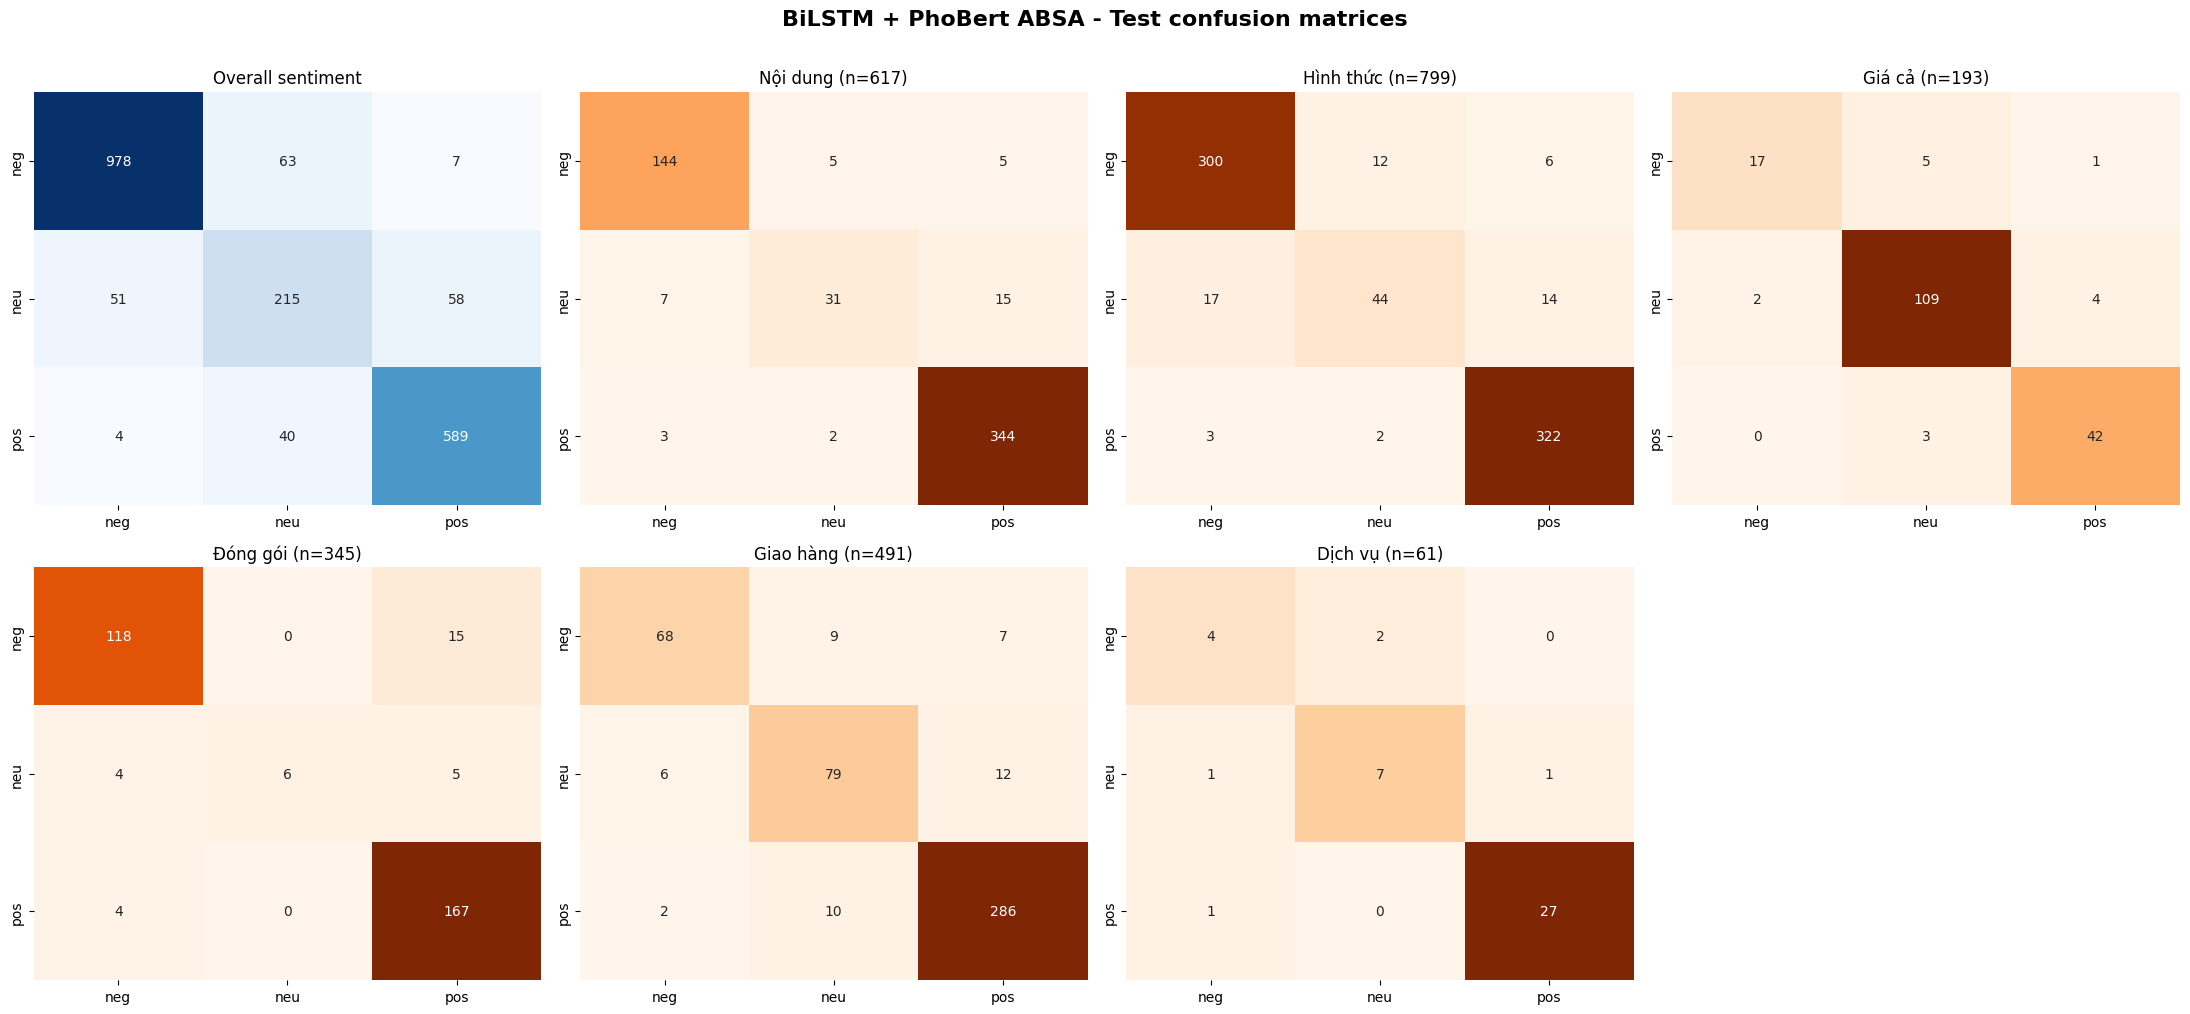

In [16]:
# Định nghĩa tên khía cạnh tiếng Việt để hiển thị cho đẹp
ASPECT_NAMES = ['Nội dung', 'Hình thức', 'Giá cả', 'Đóng gói', 'Giao hàng', 'Dịch vụ']

def plot_confusion_matrices(true_sentiment: np.ndarray, pred_sentiment: np.ndarray, true_aspects: np.ndarray, pred_aspects: np.ndarray) -> None:
    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    axes = axes.flatten()

    # Nhãn cảm xúc: 0 (tiêu cực), 1 (trung tính), 2 (tích cực)
    sent_cm = confusion_matrix(true_sentiment, pred_sentiment, labels=[0, 1, 2])
    sns.heatmap(sent_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['neg', 'neu', 'pos'], yticklabels=['neg', 'neu', 'pos'], ax=axes[0])
    axes[0].set_title('Overall sentiment')

    for idx, col in enumerate(ASPECT_COLS):
        ax = axes[idx + 1]
        # Bỏ qua các khía cạnh không xuất hiện (ABSENT_CLASS = 3) trong nhãn thực tế
        mask = true_aspects[:, idx] != ABSENT_CLASS
        if mask.sum() == 0:
            ax.set_visible(False)
            continue

        cm = confusion_matrix(true_aspects[:, idx][mask], pred_aspects[:, idx][mask], labels=[0, 1, 2])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
                    xticklabels=['neg', 'neu', 'pos'], yticklabels=['neg', 'neu', 'pos'], ax=ax)
        ax.set_title(f'{ASPECT_NAMES[idx]} (n={mask.sum()})')

    # Ẩn ô cuối cùng nếu dư
    if len(axes) > 7:
        axes[7].set_visible(False)

    plt.suptitle('BiLSTM + PhoBert ABSA - Test confusion matrices', y=1.01, fontweight='bold', fontsize=16)
    plt.tight_layout()

    # Lưu ảnh ma trận nhầm lẫn
    os.makedirs(OUTPUT_ROOT, exist_ok=True)
    plt.savefig(OUTPUT_ROOT / 'confusion_matrix_test.png', dpi=150, bbox_inches='tight')
    plt.show()

# ==========================================
# THỰC THI ĐÁNH GIÁ TRÊN TẬP TEST
# ==========================================
print("Đang đánh giá mô hình BiLSTM trên tập Test...")

# Load mô hình tốt nhất một cách an toàn (tương thích cả Single-GPU và Multi-GPU)
state_dict = torch.load(OUTPUT_ROOT / 'best_bilstm_model.pt', map_location=DEVICE)

if hasattr(model, 'module'):
    model.module.load_state_dict(state_dict)
else:
    model.load_state_dict(state_dict)

model.eval()

true_sentiment, pred_sentiment = [], []
true_aspects, pred_aspects = [], []

# Bắt đầu đo thời gian cho tập Test
start_time = time.time()

# Chạy suy luận (Inference) trên Test DataLoader
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE) 
        labels = batch['labels'].numpy()

        # Lấy Logits từ mô hình, truyền attention_mask vào
        sent_logits, pres_logits, asp_logits, _ = model(input_ids, attention_mask)

        # Lấy nhãn dự đoán bằng argmax
        p_sent = sent_logits.argmax(dim=-1).cpu().numpy()
        p_pres = pres_logits.argmax(dim=-1).cpu().numpy()
        p_asp_sent = asp_logits.argmax(dim=-1).cpu().numpy()

        # Logic ghép nhãn: Nếu presence = 0 (không xuất hiện) -> gán nhãn ABSENT_CLASS (3)
        p_asp = np.where(p_pres == 0, ABSENT_CLASS, p_asp_sent)

        # Lưu trữ kết quả
        true_sentiment.extend(labels[:, 0])
        pred_sentiment.extend(p_sent)
        true_aspects.extend(labels[:, 1:])
        pred_aspects.extend(p_asp)

# Kết thúc đo thời gian và tính toán tốc độ
end_time = time.time()
test_runtime = end_time - start_time
num_samples = len(true_sentiment)
num_steps = len(test_loader)

test_samples_per_second = num_samples / test_runtime if test_runtime > 0 else 0
test_steps_per_second = num_steps / test_runtime if test_runtime > 0 else 0

# Chuyển đổi sang Numpy Array
true_sentiment = np.array(true_sentiment)
pred_sentiment = np.array(pred_sentiment)
true_aspects = np.array(true_aspects)
pred_aspects = np.array(pred_aspects)

# 3. In Báo cáo phân loại (Classification Report)
print('\n=========================================')
print('=== BÁO CÁO TỔNG THỂ (OVERALL SENTIMENT) ===')
print('=========================================')
print(classification_report(
    true_sentiment,
    pred_sentiment,
    labels=[0, 1, 2],
    target_names=['neg', 'neu', 'pos'],
    zero_division=0
))

# ==========================================
# 5. BÁO CÁO TRUNG BÌNH TOÀN BỘ ASPECT (present only)
# ==========================================

all_true = []
all_pred = []

for idx in range(len(ASPECT_COLS)):
    t_asp = true_aspects[:, idx]
    p_asp = pred_aspects[:, idx]

    mask = t_asp != ABSENT_CLASS  # chỉ lấy các aspect có xuất hiện

    if mask.sum() == 0:
        continue

    all_true.extend(t_asp[mask])
    all_pred.extend(p_asp[mask])

all_true = np.array(all_true)
all_pred = np.array(all_pred)

print('\n=========================================')
print('=== Báo Cáo Mean 6 ASPECTS')
print('=========================================')

print(classification_report(
    all_true,
    all_pred,
    labels=[0, 1, 2],
    target_names=['neg', 'neu', 'pos'],
    zero_division=0
))

print('\n=========================================')
print('=== BÁO CÁO CHI TIẾT TỪNG KHÍA CẠNH ===')
print('=========================================')
for idx, (col_name, aspect_name) in enumerate(zip(ASPECT_COLS, ASPECT_NAMES)):
    # Lấy nhãn thực tế và nhãn dự đoán cho khía cạnh hiện tại
    t_asp = true_aspects[:, idx]
    p_asp = pred_aspects[:, idx]

    # Tạo mask để lọc bỏ những mẫu không chứa khía cạnh này (ABSENT_CLASS)
    mask = t_asp != ABSENT_CLASS

    print(f'\n--- Khía cạnh: {aspect_name.upper()} (n = {mask.sum()}) ---')

    if mask.sum() > 0:
        print(classification_report(
            t_asp[mask],
            p_asp[mask],
            labels=[0, 1, 2],
            target_names=['neg', 'neu', 'pos'],
            zero_division=0
        ))
    else:
        print(f"Không có dữ liệu thực tế cho khía cạnh này trong tập Test.")

# ==========================================
# TÍNH TOÁN VÀ IN DICTIONARY THÔNG SỐ TEST
# ==========================================
test_f1_sentiment = f1_score(true_sentiment, pred_sentiment, average='macro', zero_division=0)
test_f1_aspect_present = f1_score(all_true, all_pred, labels=[0, 1, 2], average='macro', zero_division=0)
test_f1_final = 0.5 * test_f1_sentiment + 0.5 * test_f1_aspect_present

test_metrics_dict = {
    'test_f1_sentiment': float(test_f1_sentiment),
    'test_f1_aspect_present': float(test_f1_aspect_present),
    'test_f1_final': float(test_f1_final),
    'test_runtime': float(test_runtime),
    'test_samples_per_second': float(test_samples_per_second),
    'test_steps_per_second': float(test_steps_per_second)
}

print('\n=========================================')
print('=== TỔNG HỢP METRICS ĐÁNH GIÁ TẬP TEST ===')
print('=========================================')
print(test_metrics_dict)

# Vẽ và lưu Ma trận nhầm lẫn (Confusion Matrices)
plot_confusion_matrices(true_sentiment, pred_sentiment, true_aspects, pred_aspects)

## DEMO

In [15]:
# Định nghĩa map nhãn
SENTIMENT_MAP = {0: "Tiêu cực", 1: "Trung tính", 2: "Tích cực"}
ASPECT_NAMES_VI = ['Nội dung', 'Hình thức', 'Giá cả', 'Đóng gói', 'Giao hàng', 'Dịch vụ']

def predict_single_review_with_confidence(text, model, tokenizer, max_len=160): # Đảm bảo max_len khớp với lúc train
    model.eval()

    # 1. Tiền xử lý
    text_seg = ViTokenizer.tokenize(text.lower())

    # 2. Tokenization
    encoding = tokenizer(
        text_seg,
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(DEVICE)
    attention_mask = encoding['attention_mask'].to(DEVICE)

    # 3. Suy luận & Tính xác suất (Softmax)
    with torch.no_grad():
        sent_logits, pres_logits, asp_logits, _ = model(input_ids, attention_mask)

        # Chuyển Logits thành Xác suất (Probabilities)
        sent_probs = F.softmax(sent_logits, dim=-1).cpu().numpy()[0]
        pres_probs = F.softmax(pres_logits, dim=-1).cpu().numpy()[0]
        asp_probs = F.softmax(asp_logits, dim=-1).cpu().numpy()[0]

        # Dự đoán Cảm xúc tổng thể (Vẫn dùng argmax vì đây là Multi-class)
        p_sent = sent_probs.argmax()
        sent_conf = sent_probs[p_sent] * 100

        # --- CẢI TIẾN: SỬ DỤNG THRESHOLD RIÊNG CHO TỪNG KHÍA CẠNH ---
        # 0:'Nội dung', 1:'Hình thức', 2:'Giá cả', 3:'Đóng gói', 4:'Giao hàng', 5:'Dịch vụ'
        # Thiết lập ngưỡng riêng (Tùy chỉnh theo lúc bạn phân tích file error_analysis.csv)
        ASPECT_THRESHOLDS = np.array([
            0.98,  # Nội dung: Ép thật cao (90%) vì mô hình rất hay đoán nhầm khía cạnh này
            0.40,  # Hình thức: Giữ vừa phải
            0.50,  # Giá cả
            0.30,  # Đóng gói: Hạ thấp để dễ bắt (30%)
            0.60,  # Giao hàng
            0.70   # Dịch vụ: Tăng lên chút để tránh nhận diện sai (như trong câu 2)
        ])

        # Lấy mảng xác suất của nhãn 1 (Có xuất hiện)
        prob_is_present = pres_probs[:, 1]

        # So sánh từng khía cạnh với ngưỡng tương ứng của nó
        p_pres = (prob_is_present >= ASPECT_THRESHOLDS).astype(int)

        # Cảm xúc của khía cạnh (Vẫn dùng argmax)
        p_asp_sent = asp_probs.argmax(axis=-1)

    # 4. In kết quả trực quan
    print("=" * 60)
    print(f"📝 BÌNH LUẬN GỐC : {text}")
    print(f"🔍 ĐÃ TÁCH TỪ    : {text_seg}")
    print("-" * 60)
    print(f"⭐ ĐÁNH GIÁ CHUNG: {SENTIMENT_MAP[p_sent]} (Độ tự tin: {sent_conf:.1f}%)")
    print("-" * 60)
    print("📌 CHI TIẾT CÁC KHÍA CẠNH:")

    aspect_count = 0
    for idx, aspect_name in enumerate(ASPECT_NAMES_VI):
        # Xác suất mô hình cho rằng khía cạnh này CÓ xuất hiện (nhãn 1)
        presence_conf = pres_probs[idx][1] * 100

        if p_pres[idx] == 0:
            # print(f"   ~ [Bỏ qua] {aspect_name:<10}: (Chỉ đạt {presence_conf:.1f}% xuất hiện)")
            continue
        else:
            aspect_count += 1
            sentiment_conf = asp_probs[idx][p_asp_sent[idx]] * 100
            print(f"   - {aspect_name:<10}: {SENTIMENT_MAP[p_asp_sent[idx]]:<15} | Tự tin nhận diện: {presence_conf:.1f}% | Tự tin cảm xúc: {sentiment_conf:.1f}%")

    if aspect_count == 0:
        print("   (Không phát hiện khía cạnh cụ thể nào)")
    print("=" * 60 + "\n")


MODEL_PATH = '/kaggle/working/absa_bilstm_phobert/best_bilstm_model.pt'

# Load model (Đổi tên model_pb thành model để khớp với tên biến đã khởi tạo ở cell 7)
state_dict = torch.load(MODEL_PATH, map_location=DEVICE)

if hasattr(model, 'module'):
    model.module.load_state_dict(state_dict)
else:
    model.load_state_dict(state_dict)

test_reviews = [
    "Sách bọc màng co cẩn thận, giao hàng siêu nhanh nhưng nội dung đọc hơi chán, không như kỳ vọng.",
    "bìa xinh lắm ạ vì mua vào ngày 11/11 nên săn sale rẻ, nhưng shipper thái độ quá tệ, cọc cằn rất khó chịu.",
    "Tôi thấy bình thường, mua về chưa đọc tới nên không biết bên trong thế nào."
]

for review in test_reviews:
    predict_single_review_with_confidence(review, model, tokenizer_pb, max_len=160)

📝 BÌNH LUẬN GỐC : Sách bọc màng co cẩn thận, giao hàng siêu nhanh nhưng nội dung đọc hơi chán, không như kỳ vọng.
🔍 ĐÃ TÁCH TỪ    : sách bọc màng co cẩn_thận , giao hàng siêu nhanh nhưng nội_dung đọc hơi chán , không như kỳ_vọng .
------------------------------------------------------------
⭐ ĐÁNH GIÁ CHUNG: Trung tính (Độ tự tin: 84.1%)
------------------------------------------------------------
📌 CHI TIẾT CÁC KHÍA CẠNH:
   - Đóng gói  : Tích cực        | Tự tin nhận diện: 99.5% | Tự tin cảm xúc: 98.0%
   - Giao hàng : Tích cực        | Tự tin nhận diện: 100.0% | Tự tin cảm xúc: 96.3%

📝 BÌNH LUẬN GỐC : bìa xinh lắm ạ vì mua vào ngày 11/11 nên săn sale rẻ, nhưng shipper thái độ quá tệ, cọc cằn rất khó chịu.
🔍 ĐÃ TÁCH TỪ    : bìa xinh lắm ạ vì mua vào ngày 11 / 11 nên săn sale rẻ , nhưng shipper thái_độ quá tệ , cọc cằn rất khó_chịu .
------------------------------------------------------------
⭐ ĐÁNH GIÁ CHUNG: Tiêu cực (Độ tự tin: 55.1%)
---------------------------------------------